In [3]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import gamma as gam
import torch
from scipy.optimize import minimize
import emcee
import sys
from scipy import integrate
sys.path.append("..")
from src.dataset import SIRModel

# Stochastic Model

In [100]:
N = 300
T = 10
X = np.zeros((T, N))
Y = np.zeros((T, N))
beta = 1.5
gamma = .5
# X[0, 0] = 1 # seed initial infected patient
h = int(0.02 * N)
X[0][:h] = 1

obs_seed = 9

In [101]:
# frequency dependent: divide force of infection by N
# to do: negative binomial noise for observed cases
np.random.seed(obs_seed)

for t in range(1, T):
    S = (1 - X[t-1]) * (1 - Y[t-1])
    I = X[t-1] * (1 - Y[t-1])

    # simulate infections
    lam = beta * I.sum() / N
    p_i = 1 - np.exp(-lam)
    X[t] = np.where(S, X[t-1] + np.random.binomial(1, p_i, N), X[t-1])

    # observational noise?
    
    # simulate recoveries
    p_r = 1 - np.exp(-gamma)
    Y[t] = np.where(I, Y[t-1] + np.random.binomial(1, p_r, N), Y[t-1])

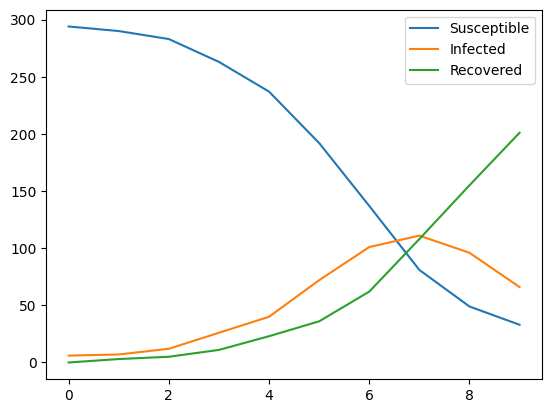

In [102]:
S = N - X.sum(1)
I = X.sum(1) - Y.sum(1)
R = Y.sum(1)

plt.plot(S, label="Susceptible")
plt.plot(I, label="Infected")
plt.plot(R, label="Recovered")
plt.legend()
plt.show()

# Likelihood-based Inference (MCMC)

In [94]:
prior_scale = [0.1, 0.1]

In [95]:
def log_prior(theta):
    if (theta <= 0).any():
        return -np.inf
    else:
        return gam(1, scale=prior_scale).logpdf(theta)

In [99]:
def log_likelihood(beta, gamma, X, Y):
    ans = 0
    T = X.shape[0]
    for t in range(1, T):
        S = (1 - X[t-1]) * (1 - Y[t-1])
        I = X[t-1] * (1 - Y[t-1])
        lam = beta * I.sum() / N
        ans += (
            S * X[t] * np.log(1 - np.exp(-lam))
        ).sum()
        ans += (
            S * (1 - X[t]) * -lam 
        ).sum()
        ans += (
            I * Y[t] * np.log(1 - np.exp(-gamma))
        ).sum()
        ans += (
            I * (1 - Y[t]) * -gamma
        ).sum()
    return ans

## MLE

In [61]:
def f(theta, X, Y):
    beta, gamma = theta
    return - log_likelihood(X, Y, beta, gamma)

In [62]:
mle = minimize(f, x0=[0.1, 0.1], args = (X, Y), bounds=((0, None), (0, None)))

In [63]:
mle.x

array([0.29137038, 0.10626214])

## MCMC

In [100]:
def log_prob(theta, X, Y):
    lp = log_prior(theta)
    beta, gamma = theta
    return lp + log_likelihood(beta, gamma, X, Y)

In [105]:
nwalkers = 8
pos = np.array(prior_scale) + 1e-3 * np.random.randn(nwalkers, 2)
sampler = emcee.EnsembleSampler(
    nwalkers, 2, log_prob, args = (X, Y)
)
sampler.run_mcmc(pos, 2000, progress=True)

100%|██████████████████████████████████████| 2000/2000 [00:14<00:00, 140.30it/s]


State([[0.24149261 0.10636332]
 [0.23963977 0.10228645]
 [0.33496707 0.10582533]
 [0.24795441 0.10774742]
 [0.29455246 0.09968279]
 [0.32254595 0.08983473]
 [0.29686388 0.10097269]
 [0.27963029 0.10661278]], log_prob=[-644.13054791 -644.29923241 -644.47244975 -643.81040287 -643.29972141
 -645.05724766 -643.2712225  -643.04919348], blobs=[-642.77925496 -642.92569914 -642.18103238 -642.40833297 -641.35102475
 -642.73013551 -641.31231053 -641.31901834], random_state=('MT19937', array([3621007236, 3049800956,  815181079,  598469343,  980685623,
       3327419686, 1426787718, 3240705651, 2809095066, 2851182069,
        582708071, 2588690223, 3503685282,  698240558,   25929057,
       3045885512, 3147781843, 1363680810, 3209545772, 2745429575,
        799849750, 1919887967, 2817319370, 2822495659, 3716102630,
       2886027322, 1326204352,  306023007, 3547569176, 2175322515,
       2340606113, 2178717518, 3738118918, 3592371265, 2171236742,
         22709788, 2368794711,  945406301, 31849943

In [106]:
flat_samples = sampler.get_chain(discard=100, thin=50, flat=True)
flat_samples.mean(0)

array([0.28650246, 0.10736832])

In [107]:
flat_samples.std(0)

array([0.03110454, 0.01160666])

In [112]:
np.corrcoef(flat_samples.T)

array([[1.        , 0.06748697],
       [0.06748697, 1.        ]])

# Prior

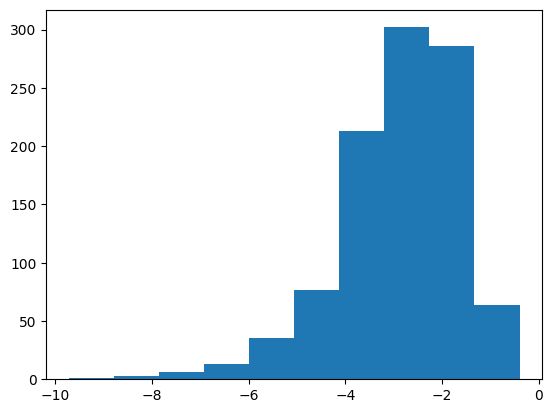

In [118]:
plt.hist(np.log(gam(1, scale=0.1).rvs(1000)))
plt.show()

In [124]:
np.exp(-2.25)

np.float64(0.10539922456186433)

# Naive Infection Model (Constant Hazard)

In [16]:
N = 300
T = 10
X = np.zeros((T, N))
Y = np.zeros((T, N))
beta = 1.5
gamma = .5
# X[0, 0] = 1 # seed initial infected patient

h = int(0.02 * N)
X[0][:h] = 1

obs_seed = 9

np.random.seed(obs_seed)

for t in range(1, T):
    S = (1 - X[t-1]) * (1 - Y[t-1])
    I = X[t-1] * (1 - Y[t-1])

    # simulate infections
    lam = beta / 10
    p_i = 1 - np.exp(-lam)
    X[t] = np.where(S, np.random.binomial(1, p_i, N), X[t-1])

    # observational noise?
    
    # simulate recoveries
    p_r = 1 - np.exp(-gamma)
    Y[t] = np.where(I, np.random.binomial(1, p_r, N), Y[t-1])

In [17]:
X.sum(1)

array([  6.,  43.,  78., 108., 130., 155., 177., 195., 211., 221.])

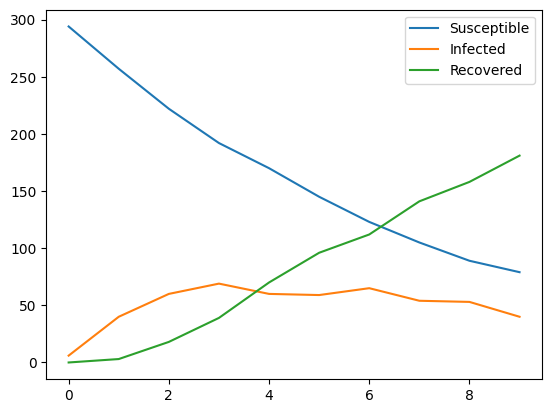

In [18]:
S = N - X.sum(1)
I = X.sum(1) - Y.sum(1)
R = Y.sum(1)

plt.plot(S, label="Susceptible")
plt.plot(I, label="Infected")
plt.plot(R, label="Recovered")
plt.legend()
plt.show()

# SIRS (Waning Immunity)

In [105]:
N = 300
T = 10
X = np.zeros((T, N))
Y = np.zeros((T, N))
A = np.zeros(N)
beta = 1.5
gamma = .5
delta = 0
# X[0, 0] = 1 # seed initial infected patient

h = int(0.02 * N)
X[0][:h] = 1

obs_seed = 9

np.random.seed(obs_seed)

for t in range(1, T):
    S = (1 - (X[t-1] - A)) * (1 - (Y[t-1] - A))
    I = (X[t-1] - A) * (1 - (Y[t-1] - A))
    R = Y[t-1] - A
    assert (S + I + R).sum() == N

    # simulate infections
    lam = beta * I.sum() / N
    p_i = 1 - np.exp(-lam)
    X[t] = np.where(S, X[t-1] + np.random.binomial(1, p_i, N), X[t-1])
    
    # simulate recoveries
    p_r = 1 - np.exp(-gamma)
    Y[t] = np.where(I, Y[t-1] + np.random.binomial(1, p_r, N), Y[t-1])

    # simulate loss of immunity
    p_s = 1 - np.exp(-delta)
    A = np.where(R, A + np.random.binomial(1, p_s, N), A)

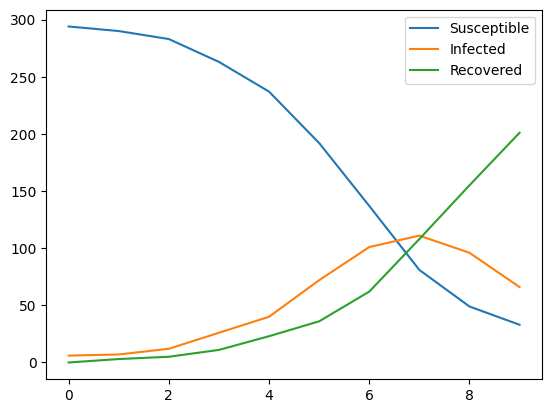

In [106]:
S = N - X.sum(1)
I = X.sum(1) - Y.sum(1)
R = Y.sum(1)

plt.plot(S, label="Susceptible")
plt.plot(I, label="Infected")
plt.plot(R, label="Recovered")
plt.legend()
plt.show()

# SEIR Model

In [ ]:
N = 300
T = 10
X = np.zeros((T, N))
Y = np.zeros((T, N))
W = np.zeros(N)
beta = 1.5
gamma = .5
sigma = 0.5
# X[0, 0] = 1 # seed initial infected patient

h = int(0.02 * N)
X[0][:h] = 1

obs_seed = 9

np.random.seed(obs_seed)

for t in range(1, T):
    S = (1 - W) * (1 - X[t-1]) * (1 - Y[t-1])
    E = W * (1 - X[t-1]) * (1 - Y[t-1])
    I = X[t-1] * (1 - Y[t-1])
    R = Y[t-1]
    assert (S + E + I + R).sum() == N

    # simulate exposure
    lam = beta * I.sum() / N
    p_e = 1 - np.exp(-lam)
    W = np.where(S, np.random.binomial(1, p_e, N), W)
    
    # simulate infections
    p_i = 1 - np.exp(-sigma)
    X[t] = np.where(E, np.random.binomial(1, p_i, N), X[t-1])
    
    # simulate recoveries
    p_r = 1 - np.exp(-gamma)
    Y[t] = np.where(I, np.random.binomial(1, p_r, N), Y[t-1])

    # simulate loss of immunity
    # p_s = 1 - np.exp(-delta)
    # A = np.where(R, A + np.random.binomial(1, p_s, N), A)

In [107]:
# crunching quantiles
def cdf(x):
    return 1 - np.exp(-x)